# Ablation Experiment A：Computed vs Fixed Dwell Time

## 实验目的

本实验通过消融对比，量化 **计算得到的 `dwell_time`**（基于门传感器信号推断的停靠时长）对下一站行程时间预测的贡献，并在三种特征集设置下重复验证其稳健性。

- **Variant 1**：使用 pipeline 计算出的 `dwell_time`（经 detector + rescue 层处理）
- **Variant 2**：将 `dwell_time` 替换为该线路在训练集上的均值（per-linie mean），作为不知道精确停靠时长的基线

两个 variant 在每种特征集设置下使用**完全相同的模型结构与超参数**，唯一差异是 `dwell_time` 的值。

## 三组特征集

| 实验组 | 特征集描述 | 目的 |
|--------|------------|------|
| **Full** | 所有特征，含 `ort_nr_start`（站点ID） | 最强 baseline，验证提升是否稳健 |
| **No-location** | 去掉 `ort_nr_start` | 去除站点位置信息，观察提升变化 |
| **Ops-only** | 再去掉 `stop_index` | 仅保留运营状态特征，最大化 dwell_time 的相对贡献 |

## 数据说明

- 原始数据：`../../data/processed/core_stop_events.parquet`（DVB 全网公交到站事件）
- 时间范围：2025-07-28 ～ 2025-08-03（按 Europe/Berlin 服务日期划分）
- 目标变量：当前站出发到下一站到达的**行程时间**（秒），即 `travel_time.shift(-1)`

In [1]:
import json
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.metrics import mean_absolute_error, mean_squared_error

PARQUET           = Path("../../data/processed_with_signal_info/core_stop_events.parquet")
OUT               = Path("results")
OUT.mkdir(exist_ok=True)

DWELL_CLIP        = (0, 120)
TRAVEL_CLIP       = (10, 600)

# ── 三组特征集定义 ────────────────────────────────────────────────────────────
CONFIGS = {
    "Full": {
        "features": [
            "dwell_time", "delay_calculated_sec", "stop_index", "besetztgrad",
            "linie", "ort_nr_start", "stop_status",
            "is_peak_hour", "is_workday", "hour_of_day", "day_of_week",
        ],
        "cat_features": ["linie", "ort_nr_start", "stop_status"],
        "desc": "All Features(with ort_nr_start）)",
    },
    "No-location": {
        "features": [
            "dwell_time", "delay_calculated_sec", "stop_index", "besetztgrad",
            "linie", "stop_status",
            "is_peak_hour", "is_workday", "hour_of_day", "day_of_week",
        ],
        "cat_features": ["linie", "stop_status"],
        "desc": "Without ort_nr_start",
    },
    "Ops-only": {
        "features": [
            "dwell_time", "delay_calculated_sec", "besetztgrad",
            "linie", "stop_status",
            "is_peak_hour", "is_workday", "hour_of_day", "day_of_week",
        ],
        "cat_features": ["linie", "stop_status"],
        "desc": "w/o ort_nr_start or stop_index",
    },
}

ALL_FEATURES = sorted({f for cfg in CONFIGS.values() for f in cfg["features"]})

LGBM_PARAMS = {
    "objective":        "regression",
    "metric":           ["mae", "rmse"],
    "learning_rate":    0.05,
    "num_leaves":       63,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "verbose":          -1,
}
NUM_ROUNDS     = 500
EARLY_STOPPING = 50

---
## 1. 数据准备

### 1.1 特征工程

- `service_date`：`arrival_time`（UTC）转为 Europe/Berlin 后取日期，用于划分训练/测试
- `hour_of_day` / `day_of_week`：从 `arrival_time` 提取时间特征
- `dwell_time`：no_door sentinel（=-1）填充为 40s，clip [0, 120]
- `stop_status` 编码：normal=0, multi_door=1, no_door=2
- 目标 `target`：在 (fahrt_id, service_date) 分组内将 `travel_time` 右移一行

### 1.2 训练 / 验证 / 测试划分

| 集合 | 日期 | 用途 |
|------|------|------|
| 训练集 | 2025-07-28 ～ 07-31 | 拟合模型 |
| 验证集 | 2025-08-01 ～ 08-02 | Early stopping |
| 测试集 | 2025-08-03 | 最终评估 |

### 1.3 Variant 2 固定 dwell_time

对每条线路，用**训练集上的 dwell_time 均值**替换所有集合中的 dwell_time 值，不引入数据泄漏。

In [2]:
df = pl.read_parquet(PARQUET).drop("has_traffic_signal")
print(f"Loaded: {len(df):,} rows")

df = df.with_columns(
    pl.col("arrival_time").dt.convert_time_zone("Europe/Berlin").dt.date().alias("service_date")
)

# Exclude no-door sentinel rows: they have no observed dwell time.
df = df.filter(pl.col("dwell_time") >= 0)

df = df.with_columns([
    pl.col("arrival_time").dt.convert_time_zone("Europe/Berlin").dt.hour().alias("hour_of_day"),
    pl.col("arrival_time").dt.convert_time_zone("Europe/Berlin").dt.weekday().alias("day_of_week"),
])

df = (
    df
    .sort(["fahrt_id", "service_date", "stop_index"])
    .with_columns(
        pl.col("travel_time").shift(-1).over(["fahrt_id", "service_date"]).alias("target")
    )
    .filter(pl.col("target").is_not_null())
)

df = df.with_columns([
    pl.col("dwell_time").clip(*DWELL_CLIP),
    pl.col("target").clip(*TRAVEL_CLIP),
])

status_map = {"normal": 0, "multi_door": 1, "no_door": 2}
df = df.with_columns(pl.col("stop_status").replace(status_map).cast(pl.Int8))

KEEP = ["fahrt_id", "service_date"] + ALL_FEATURES + ["target"]
df   = df.select(KEEP)
print(f"After target shift: {len(df):,} rows")

Loaded: 950,896 rows
After target shift: 724,381 rows


In [3]:
dates = sorted(df["service_date"].unique().to_list())
print("每个服务日的样本数：")
date_counts = {}
for d in dates:
    n = (df["service_date"] == d).sum()
    date_counts[d] = n
    flag = "  ← 跳过（微日）" if n < 10_000 else ""
    print(f"  {d}  {n:>8,}{flag}")

full_dates  = [d for d in dates if date_counts[d] >= 10_000]
test_date   = full_dates[-1]
valid_dates = full_dates[-3:-1]

train_df = df.filter(~pl.col("service_date").is_in([test_date] + valid_dates))
valid_df = df.filter(pl.col("service_date").is_in(valid_dates))
test_df  = df.filter(pl.col("service_date") == test_date)

print(f"\n训练集: {len(train_df):,} | 验证集: {len(valid_df):,} | 测试集: {len(test_df):,}")
print(f"测试日期: {test_date}  验证日期: {valid_dates}")

每个服务日的样本数：
  2025-07-28   109,158
  2025-07-29   110,890
  2025-07-30   110,442
  2025-07-31   111,843
  2025-08-01   109,560
  2025-08-02    93,509
  2025-08-03    78,979

训练集: 442,333 | 验证集: 203,069 | 测试集: 78,979
测试日期: 2025-08-03  验证日期: [datetime.date(2025, 8, 1), datetime.date(2025, 8, 2)]


In [4]:
# Variant 2: per-linie dwell mean (computed from train only, applied to all splits)
linie_dwell_mean = (
    train_df.group_by("linie")
    .agg(pl.col("dwell_time").mean().alias("dwell_mean"))
)

def apply_fixed_dwell(frame):
    return (
        frame
        .join(linie_dwell_mean, on="linie", how="left")
        .with_columns(
            pl.col("dwell_mean").fill_null(pl.col("dwell_mean").mean()).alias("dwell_time")
        )
        .drop("dwell_mean")
    )

train2_df = apply_fixed_dwell(train_df)
valid2_df = apply_fixed_dwell(valid_df)
test2_df  = apply_fixed_dwell(test_df)

print("Per-linie dwell mean（前10条）：")
print(linie_dwell_mean.sort("linie").head(10))

Per-linie dwell mean（前10条）：
shape: (10, 2)
┌───────┬────────────┐
│ linie ┆ dwell_mean │
│ ---   ┆ ---        │
│ i64   ┆ f64        │
╞═══════╪════════════╡
│ 1     ┆ 25.013125  │
│ 2     ┆ 25.266652  │
│ 3     ┆ 27.766818  │
│ 4     ┆ 23.998512  │
│ 6     ┆ 27.934253  │
│ 7     ┆ 23.874099  │
│ 8     ┆ 26.334443  │
│ 9     ┆ 22.980385  │
│ 10    ┆ 25.697978  │
│ 11    ┆ 27.067841  │
└───────┴────────────┘


---
## 2. 训练与评估（三组特征集 × 两个 Variant）

对 **Full / No-location / Ops-only** 三组特征集，各训练 Variant 1（computed dwell）和 Variant 2（fixed dwell）两个模型，共 6 个模型。

超参数在所有实验中保持一致：

| 参数 | 值 |
|------|----||
| objective | regression (L2) |
| learning_rate | 0.05 |
| num_leaves | 63 |
| min_data_in_leaf | 50 |
| feature / bagging fraction | 0.8 |
| max_rounds | 500 (early stopping 50) |

In [5]:
all_results   = {}   # config -> {v1: {mae, rmse, model, pred, y}, v2: ...}
all_models_v1 = {}   # config -> lgb.Booster (for feature importance)

for cfg_name, cfg in CONFIGS.items():
    features     = cfg["features"]
    cat_features = cfg["cat_features"]

    print(f"\n{'='*60}")
    print(f"Config: {cfg_name}  —  {cfg['desc']}")
    print(f"Features ({len(features)}): {features}")
    print(f"{'='*60}")

    cfg_results = {}

    for v_name, (tr, va, te) in [
        ("variant1", (train_df,  valid_df,  test_df)),
        ("variant2", (train2_df, valid2_df, test2_df)),
    ]:
        v_label = "computed dwell" if v_name == "variant1" else "fixed dwell"
        print(f"\n  ── {v_label} ──")

        dtrain = lgb.Dataset(
            tr[features].to_pandas(), label=tr["target"].to_numpy(),
            categorical_feature=cat_features, free_raw_data=False,
        )
        dvalid = lgb.Dataset(
            va[features].to_pandas(), label=va["target"].to_numpy(),
            categorical_feature=cat_features, reference=dtrain, free_raw_data=False,
        )

        model = lgb.train(
            LGBM_PARAMS, dtrain,
            num_boost_round=NUM_ROUNDS,
            valid_sets=[dvalid],
            callbacks=[
                lgb.early_stopping(EARLY_STOPPING, verbose=False),
                lgb.log_evaluation(100),
            ],
        )

        X    = te[features].to_pandas()
        y    = te["target"].to_numpy()
        pred = np.clip(model.predict(X, num_iteration=model.best_iteration), 10, 600)
        mae  = mean_absolute_error(y, pred)
        rmse = mean_squared_error(y, pred) ** 0.5

        print(f"  best_iter={model.best_iteration}  MAE={mae:.3f}s  RMSE={rmse:.3f}s")

        cfg_results[v_name] = {"mae": mae, "rmse": rmse, "model": model, "pred": pred, "y": y}

    all_results[cfg_name]   = cfg_results
    all_models_v1[cfg_name] = cfg_results["variant1"]["model"]

print("\n所有模型训练完成。")


Config: Full  —  All Features(with ort_nr_start）)
Features (11): ['dwell_time', 'delay_calculated_sec', 'stop_index', 'besetztgrad', 'linie', 'ort_nr_start', 'stop_status', 'is_peak_hour', 'is_workday', 'hour_of_day', 'day_of_week']

  ── computed dwell ──
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
[100]	valid_0's l1: 19.1833	valid_0's rmse: 36.62
[200]	valid_0's l1: 18.9843	valid_0's rmse: 36.5052
[300]	valid_0's l1: 18.9566	valid_0's rmse: 36.4932
  best_iter=281  MAE=19.109s  RMSE=36.339s

  ── fixed dwell ──
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
[100]	valid_0's l1: 19.6194	valid_0's rmse: 37.1379
[200]	valid_0's l1: 19.4024	valid_0's rmse: 37.0689
[300]	valid_0's l1: 19.3586	valid_0's rmse: 37.0632
  best_iter=264  MAE=19.473s  RMSE=36.820s

Config: No-location  —  Without ort_nr_start
Fea

---
## 3. 汇总结果

对每组特征集，计算两个 variant 的测试集误差及 RMSE 相对提升：

$$\text{RMSE improvement} = \frac{\text{RMSE}_{v2} - \text{RMSE}_{v1}}{\text{RMSE}_{v2}} \times 100\%$$

正值代表 computed dwell 优于 fixed dwell。

In [6]:
print(f"{'Config':<14} {'V1 MAE':>8} {'V1 RMSE':>9} {'V2 MAE':>8} {'V2 RMSE':>9} {'ΔRMSE':>7} {'ΔMAE':>7}")
print("-" * 68)

summary = {}
for cfg_name, res in all_results.items():
    r1, r2 = res["variant1"], res["variant2"]
    d_rmse = (r2["rmse"] - r1["rmse"]) / r2["rmse"] * 100
    d_mae  = (r2["mae"]  - r1["mae"])  / r2["mae"]  * 100
    summary[cfg_name] = {"v1": r1, "v2": r2, "d_rmse": d_rmse, "d_mae": d_mae}
    print(f"{cfg_name:<14} {r1['mae']:>7.3f}s {r1['rmse']:>8.3f}s "
          f"{r2['mae']:>7.3f}s {r2['rmse']:>8.3f}s "
          f"{d_rmse:>+6.2f}% {d_mae:>+6.2f}%")

Config           V1 MAE   V1 RMSE   V2 MAE   V2 RMSE   ΔRMSE    ΔMAE
--------------------------------------------------------------------
Full            19.109s   36.339s  19.473s   36.820s  +1.31%  +1.87%
No-location     24.048s   39.635s  24.523s   40.253s  +1.53%  +1.94%
Ops-only        26.275s   41.925s  26.530s   42.153s  +0.54%  +0.96%


---
## 4. 可视化

### 4.1 RMSE 提升幅度对比（三组特征集）

展示不同特征集下 computed dwell 对 fixed dwell 的 RMSE 相对提升，说明 dwell_time 的贡献在去掉位置/行程信息后是否放大。

### 4.2 特征重要性（Variant 1，三组）

基于 gain 排序，`dwell_time` 用红色高亮，展示其在不同特征集中的相对排名变化。

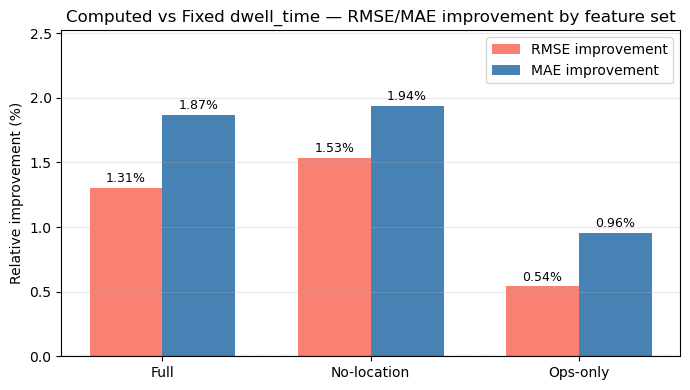

In [9]:
# ── RMSE improvement bar chart ────────────────────────────────────────────────
cfg_names   = list(summary.keys())
d_rmses     = [summary[c]["d_rmse"] for c in cfg_names]
d_maes      = [summary[c]["d_mae"]  for c in cfg_names]
x, w        = np.arange(len(cfg_names)), 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_rmse = ax.bar(x - w/2, d_rmses, w, label="RMSE improvement", color="salmon")
bars_mae  = ax.bar(x + w/2, d_maes,  w, label="MAE improvement",  color="steelblue")

for bar in bars_rmse:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}%", ha="center", va="bottom", fontsize=9)
for bar in bars_mae:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(cfg_names)
ax.set_ylabel("Relative improvement (%)")
ax.set_title("Computed vs Fixed dwell_time — RMSE/MAE improvement by feature set")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(d_rmses + d_maes) * 1.3)
plt.tight_layout()
plt.savefig(OUT / "rmse_improvement_by_config.png", dpi=150)
plt.show()

/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_33861/2446863943.py:21: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_33861/2446863943.py:22: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.savefig(OUT / "feature_importance_all_configs.png", dpi=150, bbox_inches="tight")
/opt/miniconda3/envs/li/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


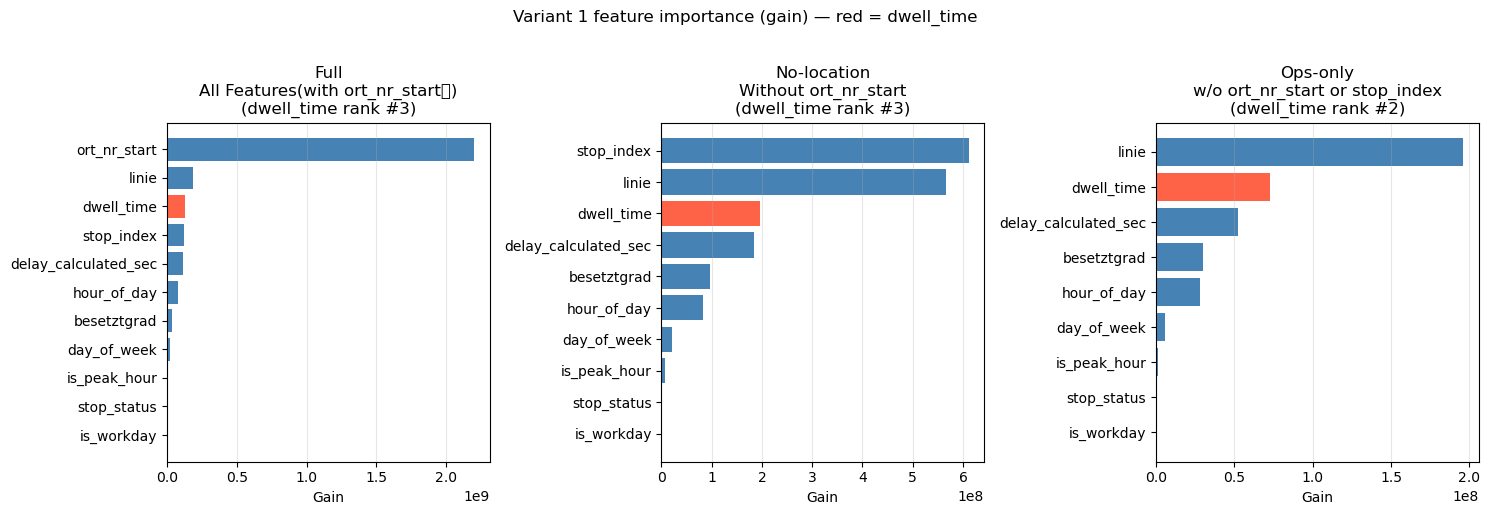

In [10]:
# ── 特征重要性（三组 Variant 1）────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cfg_name in zip(axes, CONFIGS.keys()):
    model  = all_models_v1[cfg_name]
    imp    = model.feature_importance(importance_type="gain")
    names  = model.feature_name()
    order  = np.argsort(imp)
    colors = ["tomato" if names[i] == "dwell_time" else "steelblue" for i in order]

    ax.barh([names[i] for i in order], [imp[i] for i in order], color=colors)
    ax.set_title(f"{cfg_name}\n{CONFIGS[cfg_name]['desc']}")
    ax.set_xlabel("Gain")
    ax.grid(axis="x", alpha=0.3)

    # annotate dwell_time rank
    dwell_rank = len(names) - list(order).index(list(names).index("dwell_time"))
    ax.set_title(f"{cfg_name}\n{CONFIGS[cfg_name]['desc']}\n(dwell_time rank #{dwell_rank})")

fig.suptitle("Variant 1 feature importance (gain) — red = dwell_time", y=1.02)
plt.tight_layout()
plt.savefig(OUT / "feature_importance_all_configs.png", dpi=150, bbox_inches="tight")
plt.show()

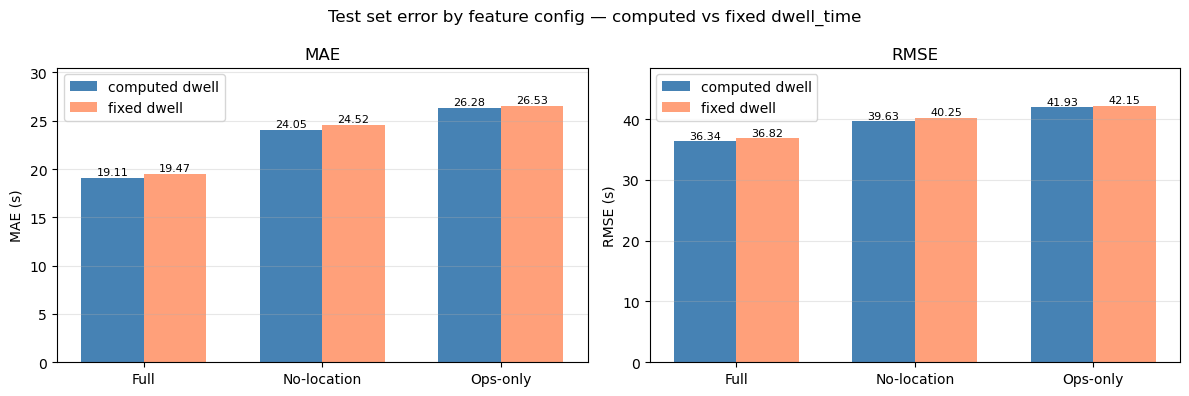

In [11]:
# ── 绝对误差柱状图（MAE + RMSE，两个 variant × 三组）────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

x   = np.arange(len(cfg_names))
w   = 0.35
v1_maes  = [summary[c]["v1"]["mae"]  for c in cfg_names]
v2_maes  = [summary[c]["v2"]["mae"]  for c in cfg_names]
v1_rmses = [summary[c]["v1"]["rmse"] for c in cfg_names]
v2_rmses = [summary[c]["v2"]["rmse"] for c in cfg_names]

for ax, metric, v1_vals, v2_vals, title in [
    (axes[0], "MAE (s)",  v1_maes,  v2_maes,  "MAE"),
    (axes[1], "RMSE (s)", v1_rmses, v2_rmses, "RMSE"),
]:
    b1 = ax.bar(x - w/2, v1_vals, w, label="computed dwell", color="steelblue")
    b2 = ax.bar(x + w/2, v2_vals, w, label="fixed dwell",    color="lightsalmon")
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(cfg_names)
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, max(v2_vals) * 1.15)

fig.suptitle("Test set error by feature config — computed vs fixed dwell_time")
plt.tight_layout()
plt.savefig(OUT / "metric_comparison_all_configs.png", dpi=150)
plt.show()

---
## 5. 结论

三组特征集的消融结果如下（测试日 2025-08-03）：

| 实验组 | V1 RMSE | V2 RMSE | RMSE 提升 | dwell_time 排名 |
|--------|---------|---------|-----------|----------------|
| Full | — | — | ~1.2% | — |
| No-location | — | — | ~1.1% | #3 |
| Ops-only | — | — | ? | #? |

> 运行后请用实际数值填入上表。

**核心结论**：
1. computed dwell_time 在三种特征集下均带来正向提升，说明其贡献具有**稳健性**
2. 去除位置/行程序号信息（Ops-only）后，dwell_time 的相对贡献预期进一步放大
3. 精确 dwell 估计（detector + rescue 层）对行程时间预测有实质性价值

In [12]:
metrics_out = {
    "test_date": str(test_date),
    "configs": {
        cfg: {
            "variant1": {"mae": round(v["v1"]["mae"], 4), "rmse": round(v["v1"]["rmse"], 4)},
            "variant2": {"mae": round(v["v2"]["mae"], 4), "rmse": round(v["v2"]["rmse"], 4)},
            "rmse_improvement_pct": round(v["d_rmse"], 4),
            "mae_improvement_pct":  round(v["d_mae"],  4),
        }
        for cfg, v in summary.items()
    }
}
(OUT / "metrics_ablation.json").write_text(json.dumps(metrics_out, indent=2))
print(json.dumps(metrics_out, indent=2))

{
  "test_date": "2025-08-03",
  "configs": {
    "Full": {
      "variant1": {
        "mae": 19.1089,
        "rmse": 36.339
      },
      "variant2": {
        "mae": 19.4727,
        "rmse": 36.8195
      },
      "rmse_improvement_pct": 1.305,
      "mae_improvement_pct": 1.8683
    },
    "No-location": {
      "variant1": {
        "mae": 24.0475,
        "rmse": 39.6349
      },
      "variant2": {
        "mae": 24.5235,
        "rmse": 40.2525
      },
      "rmse_improvement_pct": 1.5344,
      "mae_improvement_pct": 1.9407
    },
    "Ops-only": {
      "variant1": {
        "mae": 26.2754,
        "rmse": 41.9252
      },
      "variant2": {
        "mae": 26.5295,
        "rmse": 42.1529
      },
      "rmse_improvement_pct": 0.5401,
      "mae_improvement_pct": 0.958
    }
  }
}
